# Explore here

Wine Classifier with KNN

Project to predict wine quality using K-Nearest Neighbors.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# 1. Load the data
url = "https://raw.githubusercontent.com/rosinni/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(url, sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [15]:
import pandas as pd
import numpy as np
import json

# 1. Cargar el dataset del vino
url = "https://raw.githubusercontent.com/rosinni/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(url, sep=";")

# 2. Simular una columna categórica llamada 'region'
np.random.seed(42)
df["region"] = np.random.choice(["Douro", "Alentejo", "Bairrada"], size=len(df))

# 3. Factorizar la columna 'region'
df["region_n"] = pd.factorize(df["region"])[0]

# 4. Crear el diccionario de transformación
region_transformation_rules = {
    row["region"]: row["region_n"]
    for _, row in df[["region", "region_n"]].drop_duplicates().iterrows()
}

# 5. Guardar el diccionario como archivo JSON
with open("region_transformation_rules.json", "w") as f:
    json.dump(region_transformation_rules, f)

# (Opcional) Verifica los primeros registros
print(df[["region", "region_n"]].head())


     region  region_n
0  Bairrada         0
1     Douro         1
2  Bairrada         0
3  Bairrada         0
4     Douro         1


In [16]:
import pandas as pd
import json

# 1. Cargar el dataset
url = "https://raw.githubusercontent.com/rosinni/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(url, sep=";")

# 2. Agregar columna categórica simulada (si aún no la tienes)
import numpy as np
np.random.seed(42)
df["region"] = np.random.choice(["Douro", "Alentejo", "Bairrada"], size=len(df))
df["region_n"] = pd.factorize(df["region"])[0]

# 3. Crear copias del dataset con y sin outliers
df_con_outliers = df.copy()
df_sin_outliers = df.copy()

# 4. Función para reemplazar outliers en una columna
def replace_outliers_from_column(column, df):
    stats = df[column].describe()
    iqr = stats["75%"] - stats["25%"]
    upper_limit = stats["75%"] + 1.5 * iqr
    lower_limit = stats["25%"] - 1.5 * iqr
    if lower_limit < 0:
        lower_limit = 0
    df[column] = df[column].apply(lambda x: x if x <= upper_limit else upper_limit)
    df[column] = df[column].apply(lambda x: x if x >= lower_limit else lower_limit)
    return df.copy(), [lower_limit, upper_limit]

# 5. Reemplazar outliers y guardar los límites por columna
outliers_dict = {}
columns_to_check = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
                    'pH', 'sulphates', 'alcohol']

for col in columns_to_check:
    df_sin_outliers, limits = replace_outliers_from_column(col, df_sin_outliers)
    outliers_dict[col] = limits

# 6. Guardar el diccionario como JSON
with open("outliers_replacement.json", "w") as f:
    json.dump(outliers_dict, f)

# (Opcional) Ver los límites aplicados
print("Límites de reemplazo por columna:")
for col, limits in outliers_dict.items():
    print(f"{col}: {limits}")


Límites de reemplazo por columna:
fixed acidity: [np.float64(3.95), np.float64(12.349999999999998)]
volatile acidity: [np.float64(0.015000000000000013), np.float64(1.0150000000000001)]
citric acid: [0, np.float64(0.9149999999999999)]
residual sugar: [np.float64(0.8499999999999996), np.float64(3.6500000000000004)]
chlorides: [np.float64(0.04000000000000002), np.float64(0.11999999999999998)]
free sulfur dioxide: [0, np.float64(42.0)]
total sulfur dioxide: [0, np.float64(122.0)]
density: [np.float64(0.9922475000000001), np.float64(1.0011875)]
pH: [np.float64(2.925), np.float64(3.6849999999999996)]
sulphates: [np.float64(0.28000000000000014), np.float64(0.9999999999999999)]
alcohol: [np.float64(7.1000000000000005), np.float64(13.5)]


In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Cargar dataset y preparar columnas
url = "https://raw.githubusercontent.com/rosinni/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(url, sep=";")

# Simular variable categórica y factorización
np.random.seed(42)
df["region"] = np.random.choice(["Douro", "Alentejo", "Bairrada"], size=len(df))
df["region_n"] = pd.factorize(df["region"])[0]

# Crear columna de etiqueta
def quality_to_label(q):
    if q <= 4:
        return 0
    elif q <= 6:
        return 1
    else:
        return 2
df["label"] = df["quality"].apply(quality_to_label)

# Reemplazar outliers en columnas numéricas
def replace_outliers_from_column(column, df):
    stats = df[column].describe()
    iqr = stats["75%"] - stats["25%"]
    upper_limit = stats["75%"] + 1.5 * iqr
    lower_limit = stats["25%"] - 1.5 * iqr
    if lower_limit < 0:
        lower_limit = 0
    df[column] = df[column].apply(lambda x: x if x <= upper_limit else upper_limit)
    df[column] = df[column].apply(lambda x: x if x >= lower_limit else lower_limit)
    return df.copy()

# Copias con y sin outliers
df_con_outliers = df.copy()
df_sin_outliers = df.copy()
num_vars = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
            'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
            'pH', 'sulphates', 'alcohol', 'region_n']

for col in num_vars:
    df_sin_outliers = replace_outliers_from_column(col, df_sin_outliers)

# 2. Definir features y etiqueta
X_con_outliers = df_con_outliers[num_vars]
X_sin_outliers = df_sin_outliers[num_vars]
y = df["label"]

# 3. Dividir en train/test
X_train_con_outliers, X_test_con_outliers, y_train, y_test = train_test_split(
    X_con_outliers, y, test_size=0.2, random_state=42)

X_train_sin_outliers, X_test_sin_outliers = train_test_split(
    X_sin_outliers, test_size=0.2, random_state=42)

# 4. Guardar datasets (ajusta las rutas si es necesario)
X_train_con_outliers.to_excel("X_train_con_outliers.xlsx", index=False)
X_train_sin_outliers.to_excel("X_train_sin_outliers.xlsx", index=False)
X_test_con_outliers.to_excel("X_test_con_outliers.xlsx", index=False)
X_test_sin_outliers.to_excel("X_test_sin_outliers.xlsx", index=False)
y_train.to_excel("y_train.xlsx", index=False)
y_test.to_excel("y_test.xlsx", index=False)

# 5. (Opcional) Verificar
print(X_train_con_outliers.head())


     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
493            8.7             0.690         0.31             3.0      0.086   
354            6.1             0.210         0.40             1.4      0.066   
342           10.9             0.390         0.47             1.8      0.118   
834            8.8             0.685         0.26             1.6      0.088   
705            8.4             1.035         0.15             6.0      0.073   

     free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
493                 23.0                  81.0  1.00020  3.48       0.74   
354                 40.5                 165.0  0.99120  3.25       0.59   
342                  6.0                  14.0  0.99820  3.30       0.75   
834                 16.0                  23.0  0.99694  3.32       0.47   
705                 11.0                  54.0  0.99900  3.37       0.49   

     alcohol  region_n  
493     11.6         0  
354     11.9

In [18]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Cargar el dataset
url = "https://raw.githubusercontent.com/rosinni/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(url, sep=";")

# 2. Simular columna categórica y factorización
np.random.seed(42)
df["region"] = np.random.choice(["Douro", "Alentejo", "Bairrada"], size=len(df))
df["region_n"] = pd.factorize(df["region"])[0]

# 3. Crear columna de etiqueta
def quality_to_label(q):
    if q <= 4:
        return 0
    elif q <= 6:
        return 1
    else:
        return 2
df["label"] = df["quality"].apply(quality_to_label)

# 4. Reemplazo de outliers
def replace_outliers_from_column(column, df):
    stats = df[column].describe()
    iqr = stats["75%"] - stats["25%"]
    upper_limit = stats["75%"] + 1.5 * iqr
    lower_limit = stats["25%"] - 1.5 * iqr
    if lower_limit < 0:
        lower_limit = 0
    df[column] = df[column].apply(lambda x: x if x <= upper_limit else upper_limit)
    df[column] = df[column].apply(lambda x: x if x >= lower_limit else lower_limit)
    return df.copy()

df_con_outliers = df.copy()
df_sin_outliers = df.copy()

num_vars = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
            'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
            'pH', 'sulphates', 'alcohol', 'region_n']

for col in num_vars:
    df_sin_outliers = replace_outliers_from_column(col, df_sin_outliers)

# 5. Separar X e y
X_con_outliers = df_con_outliers[num_vars]
X_sin_outliers = df_sin_outliers[num_vars]
y = df["label"]

# 6. Dividir en train/test
X_train_con_outliers, X_test_con_outliers, y_train, y_test = train_test_split(
    X_con_outliers, y, test_size=0.2, random_state=42)

X_train_sin_outliers, X_test_sin_outliers = train_test_split(
    X_sin_outliers, test_size=0.2, random_state=42)

# 7. Crear carpeta para modelos si no existe
os.makedirs("models/Normalizers", exist_ok=True)

# 8. Normalizar y guardar con pickle
# CON OUTLIERS
normalizador_con_outliers = StandardScaler()
normalizador_con_outliers.fit(X_train_con_outliers)

with open("models/Normalizers/normalizador_con_outliers.pkl", "wb") as file:
    pickle.dump(normalizador_con_outliers, file)

# SIN OUTLIERS
normalizador_sin_outliers = StandardScaler()
normalizador_sin_outliers.fit(X_train_sin_outliers)

with open("models/Normalizers/normalizador_sin_outliers.pkl", "wb") as file:
    pickle.dump(normalizador_sin_outliers, file)

print("✅ Normalizadores guardados en 'models/Normalizers/'")


✅ Normalizadores guardados en 'models/Normalizers/'


In [19]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Cargar y preparar el dataset
url = "https://raw.githubusercontent.com/rosinni/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(url, sep=";")

# 2. Simular columna categórica y factorización
np.random.seed(42)
df["region"] = np.random.choice(["Douro", "Alentejo", "Bairrada"], size=len(df))
df["region_n"] = pd.factorize(df["region"])[0]

# 3. Crear columna de etiqueta
def quality_to_label(q):
    if q <= 4:
        return 0
    elif q <= 6:
        return 1
    else:
        return 2
df["label"] = df["quality"].apply(quality_to_label)

# 4. Reemplazo de outliers
def replace_outliers_from_column(column, df):
    stats = df[column].describe()
    iqr = stats["75%"] - stats["25%"]
    upper_limit = stats["75%"] + 1.5 * iqr
    lower_limit = stats["25%"] - 1.5 * iqr
    if lower_limit < 0:
        lower_limit = 0
    df[column] = df[column].apply(lambda x: x if x <= upper_limit else upper_limit)
    df[column] = df[column].apply(lambda x: x if x >= lower_limit else lower_limit)
    return df.copy()

df_con_outliers = df.copy()
df_sin_outliers = df.copy()

num_vars = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
            'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
            'pH', 'sulphates', 'alcohol', 'region_n']

for col in num_vars:
    df_sin_outliers = replace_outliers_from_column(col, df_sin_outliers)

# 5. Separar X e y
X_con_outliers = df_con_outliers[num_vars]
X_sin_outliers = df_sin_outliers[num_vars]
y = df["label"]

# 6. Dividir en train/test
X_train_con_outliers, X_test_con_outliers, y_train, y_test = train_test_split(
    X_con_outliers, y, test_size=0.2, random_state=42)

X_train_sin_outliers, X_test_sin_outliers = train_test_split(
    X_sin_outliers, test_size=0.2, random_state=42)

# 7. Normalizar los datos usando StandardScaler
scaler_con = StandardScaler()
scaler_sin = StandardScaler()

X_train_con_scaled = scaler_con.fit_transform(X_train_con_outliers)
X_test_con_scaled = scaler_con.transform(X_test_con_outliers)

X_train_sin_scaled = scaler_sin.fit_transform(X_train_sin_outliers)
X_test_sin_scaled = scaler_sin.transform(X_test_sin_outliers)

# 8. Reconstruir como DataFrames
X_train_con_scaled_df = pd.DataFrame(X_train_con_scaled, columns=num_vars)
X_test_con_scaled_df = pd.DataFrame(X_test_con_scaled, columns=num_vars)
X_train_sin_scaled_df = pd.DataFrame(X_train_sin_scaled, columns=num_vars)
X_test_sin_scaled_df = pd.DataFrame(X_test_sin_scaled, columns=num_vars)

# 9. Guardar en archivos Excel
os.makedirs("data/processed", exist_ok=True)

X_train_con_scaled_df.to_excel("data/processed/X_train_con_outliers_norm.xlsx", index=False)
X_test_con_scaled_df.to_excel("data/processed/X_test_con_outliers_norm.xlsx", index=False)
X_train_sin_scaled_df.to_excel("data/processed/X_train_sin_outliers_norm.xlsx", index=False)
X_test_sin_scaled_df.to_excel("data/processed/X_test_sin_outliers_norm.xlsx", index=False)

print("✅ Datasets normalizados guardados en 'data/processed/'")


✅ Datasets normalizados guardados en 'data/processed/'


In [21]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. Load dataset
url = "https://raw.githubusercontent.com/rosinni/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(url, sep=";")

# 2. Simulate a categorical column and factorize it
np.random.seed(42)
df["region"] = np.random.choice(["Douro", "Alentejo", "Bairrada"], size=len(df))
df["region_n"] = pd.factorize(df["region"])[0]

# 3. Create label column
def quality_to_label(q):
    if q <= 4:
        return 0
    elif q <= 6:
        return 1
    else:
        return 2
df["label"] = df["quality"].apply(quality_to_label)

# 4. Replace outliers
def replace_outliers_from_column(column, df):
    stats = df[column].describe()
    iqr = stats["75%"] - stats["25%"]
    upper_limit = stats["75%"] + 1.5 * iqr
    lower_limit = stats["25%"] - 1.5 * iqr
    if lower_limit < 0:
        lower_limit = 0
    df[column] = df[column].apply(lambda x: x if x <= upper_limit else upper_limit)
    df[column] = df[column].apply(lambda x: x if x >= lower_limit else lower_limit)
    return df.copy()

df_con_outliers = df.copy()
df_sin_outliers = df.copy()

num_vars = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
            'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
            'pH', 'sulphates', 'alcohol', 'region_n']

for col in num_vars:
    df_sin_outliers = replace_outliers_from_column(col, df_sin_outliers)

# 5. Define X and y
X_con_outliers = df_con_outliers[num_vars]
X_sin_outliers = df_sin_outliers[num_vars]
y = df["label"]

# 6. Split train/test
X_train_con_outliers, X_test_con_outliers, y_train, y_test = train_test_split(
    X_con_outliers, y, test_size=0.2, random_state=42)

X_train_sin_outliers, X_test_sin_outliers = train_test_split(
    X_sin_outliers, test_size=0.2, random_state=42)

# 7. Create folders
os.makedirs("models/Scalers", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

# 8. Min-Max Scaling and saving scalers with pickle
# With outliers
scaler_con = MinMaxScaler()
scaler_con.fit(X_train_con_outliers)

with open("models/Scalers/scaler_con_outliers.pkl", "wb") as f:
    pickle.dump(scaler_con, f)

X_train_con_scaled = scaler_con.transform(X_train_con_outliers)
X_test_con_scaled = scaler_con.transform(X_test_con_outliers)

# Without outliers
scaler_sin = MinMaxScaler()
scaler_sin.fit(X_train_sin_outliers)

with open("models/Scalers/scaler_sin_outliers.pkl", "wb") as f:
    pickle.dump(scaler_sin, f)

X_train_sin_scaled = scaler_sin.transform(X_train_sin_outliers)
X_test_sin_scaled = scaler_sin.transform(X_test_sin_outliers)

# 9. Convert to DataFrames
X_train_con_scaled_df = pd.DataFrame(X_train_con_scaled, columns=num_vars)
X_test_con_scaled_df = pd.DataFrame(X_test_con_scaled, columns=num_vars)
X_train_sin_scaled_df = pd.DataFrame(X_train_sin_scaled, columns=num_vars)
X_test_sin_scaled_df = pd.DataFrame(X_test_sin_scaled, columns=num_vars)

# 10. Save to Excel
X_train_con_scaled_df.to_excel("data/processed/X_train_con_outliers_scal.xlsx", index=False)
X_test_con_scaled_df.to_excel("data/processed/X_test_con_outliers_scal.xlsx", index=False)
X_train_sin_scaled_df.to_excel("data/processed/X_train_sin_outliers_scal.xlsx", index=False)
X_test_sin_scaled_df.to_excel("data/processed/X_test_sin_outliers_scal.xlsx", index=False)

print("✅ Scalers saved and datasets exported to Excel.")


✅ Scalers saved and datasets exported to Excel.


In [4]:
# 2. Separate independent variables (X) and the target variable (y)
X = df.drop(["label", "quality"], axis=1)
y = df["label"]

In [5]:
# 3. Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# 4. Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# 5. Train the model with initial k = 5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.84375

Confusion Matrix:
 [[  0  11   0]
 [  1 250  11]
 [  0  27  20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.87      0.95      0.91       262
           2       0.65      0.43      0.51        47

    accuracy                           0.84       320
   macro avg       0.50      0.46      0.47       320
weighted avg       0.81      0.84      0.82       320



In [8]:
# 6. Search for the best value of k
k_range = range(1, 21)
accuracies = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_k_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_k_pred))

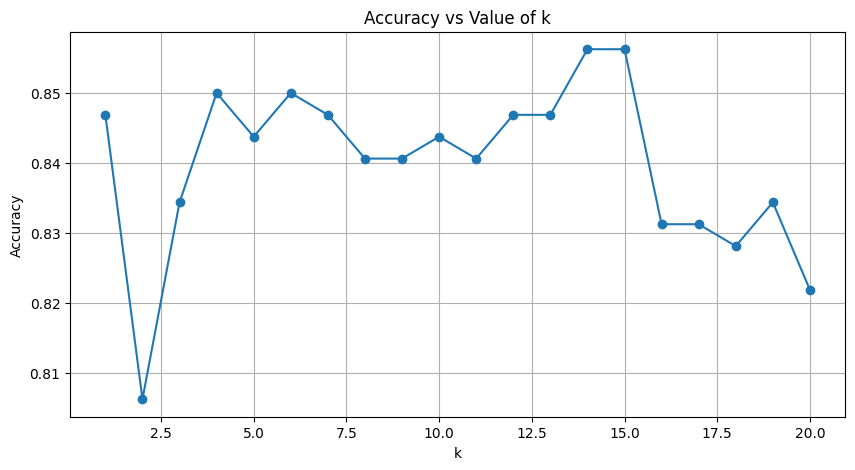

In [9]:
# 7. Plot accuracy vs k
plt.figure(figsize=(10, 5))
plt.plot(k_range, accuracies, marker='o')
plt.title("Accuracy vs Value of k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [10]:
# 8. Choose the best k
best_k = k_range[accuracies.index(max(accuracies))]
print(f"Best value of k: {best_k}")

Best value of k: 14


In [11]:
# 9. Train the final model
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=14)

In [12]:
# 10. Function to predict wine quality
def predict_wine_quality(features):
    features_scaled = scaler.transform([features])
    pred = final_knn.predict(features_scaled)[0]
    if pred == 0:
        return "This wine is likely of low quality 🍷"
    elif pred == 1:
        return "This wine is likely of medium quality 🍷"
    else:
        return "This wine is likely of high quality 🍷"

In [13]:
# 11. Test the function
result = predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076,
                               11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])
print("\nExample prediction:", result)


Example prediction: This wine is likely of medium quality 🍷


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
